In [1]:
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['axes.unicode_minus'] = False

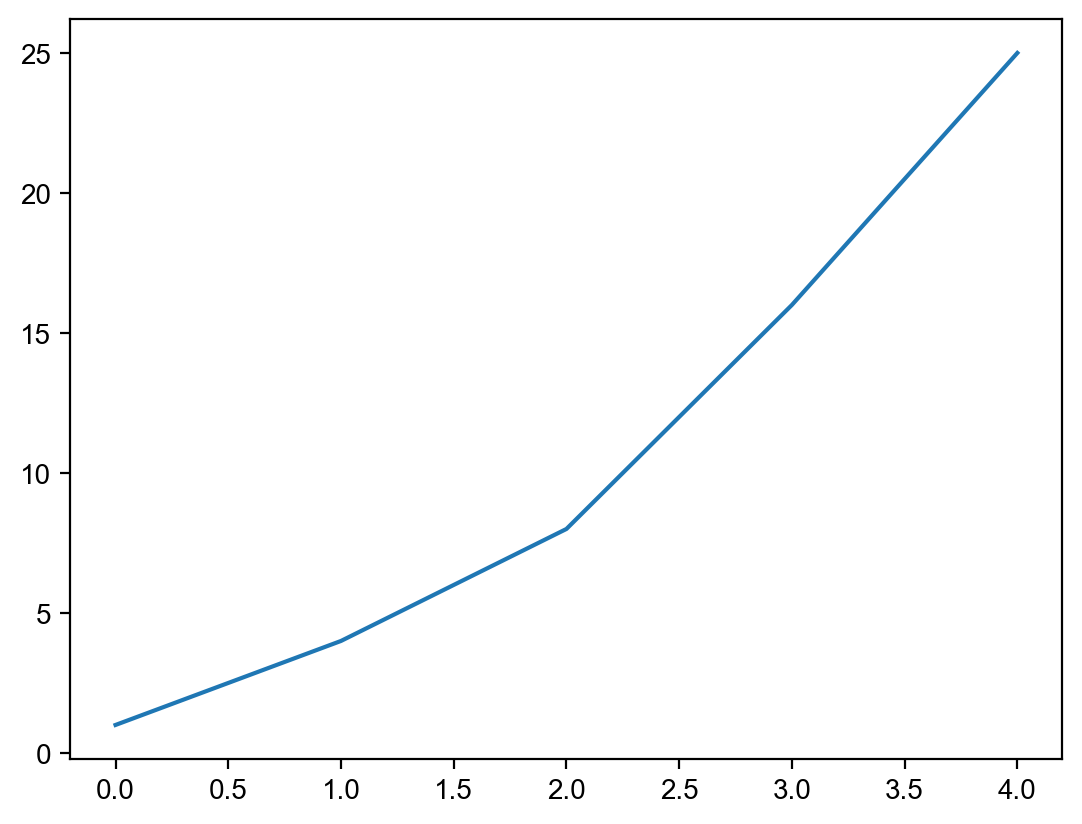

In [2]:
squares = [1, 4, 8, 16, 25]
fig, ax = plt.subplots()
ax.plot(squares)

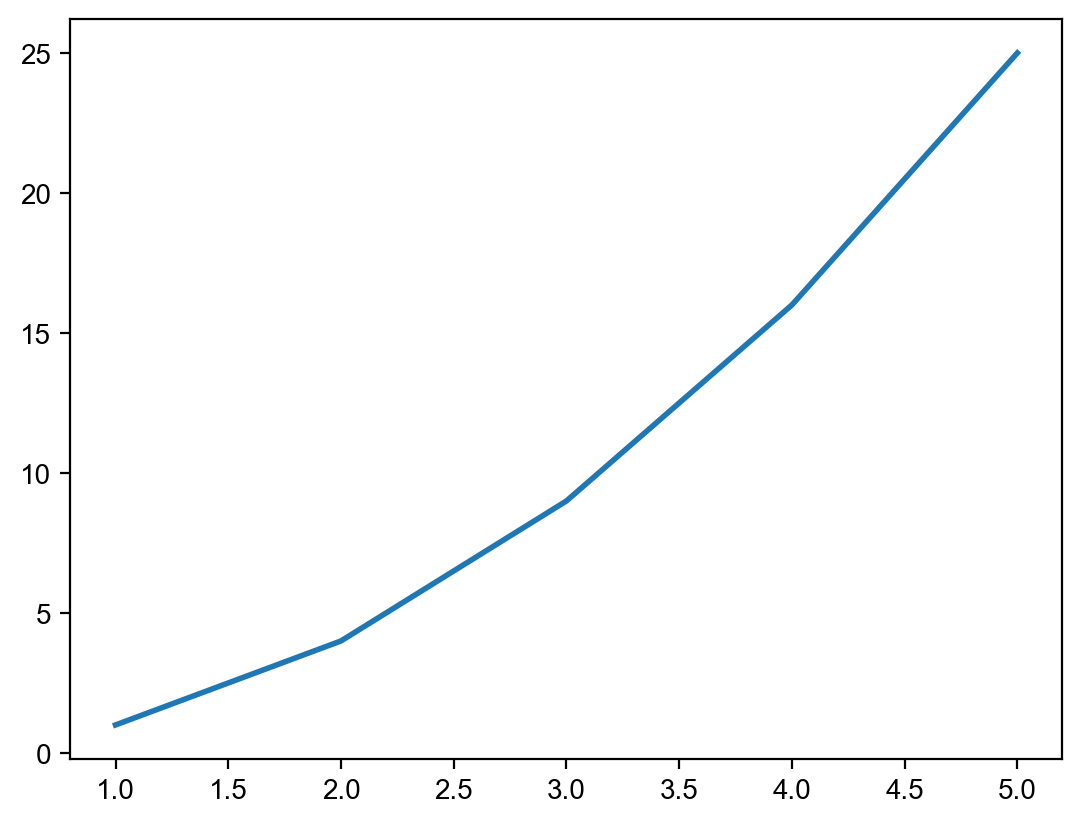

In [3]:
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]
#plt.style.available
#plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots()
ax.plot(x, y, linewidth=2)

In [4]:
# 随机游走
from random import choice


class RandomWalk:
    def __init__(self, numpoints=10000):
        self.numpoints = numpoints
        self.x_values = [0]
        self.y_values = [0]

    def fill_walk(self):
        while (len(self.x_values) < self.numpoints):
            x_direction = choice([-1, 1])
            x_distacne = choice([1, 2, 3, 4])
            x_step = x_direction*x_distacne

            y_direction = choice([-1, 1])
            y_distance = choice([1, 2, 3, 4, 5, 6, 7, 8])
            y_step = y_direction*y_distance
            if x_step == 0 and y_step == 0:
                continue

            x = self.x_values[-1]+x_step
            y = self.y_values[-1]+y_step
            self.x_values.append(x)
            self.y_values.append(y)

    def  get_step(self):
        self.direction=choice([-1, 1])
        self.distance=choice([1,2,3,4])
        self.step = self.direction*self.distance
        return self.step


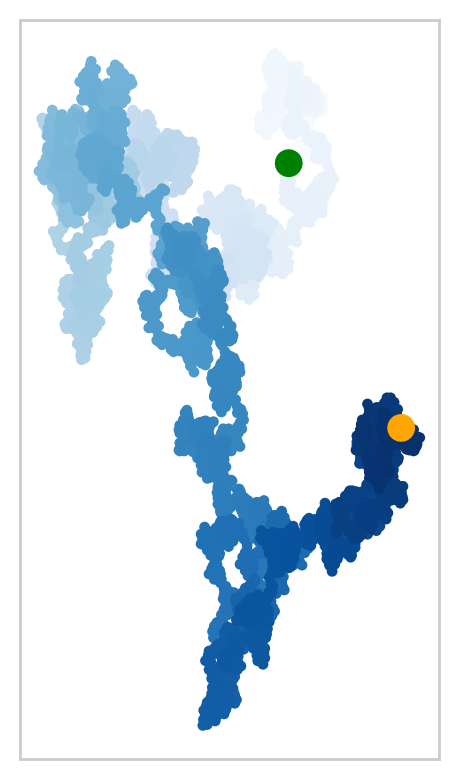

In [5]:
rw = RandomWalk()
rw.fill_walk()
plt.style.available
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots()
point_numbers = range(rw.numpoints)
ax.scatter(rw.x_values,
           rw.y_values,
           s=15,  # 形状大小
           c=point_numbers,
           cmap=plt.cm.Blues,  # 颜色映射
           edgecolors='none'  # 标记边框的颜色
           )
ax.scatter(0, 0, c='green', s=100, edgecolors='none')
ax.scatter(rw.x_values[-1], rw.y_values[-1], c='orange', s=100, edgecolors='none')
ax.set_aspect('equal')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

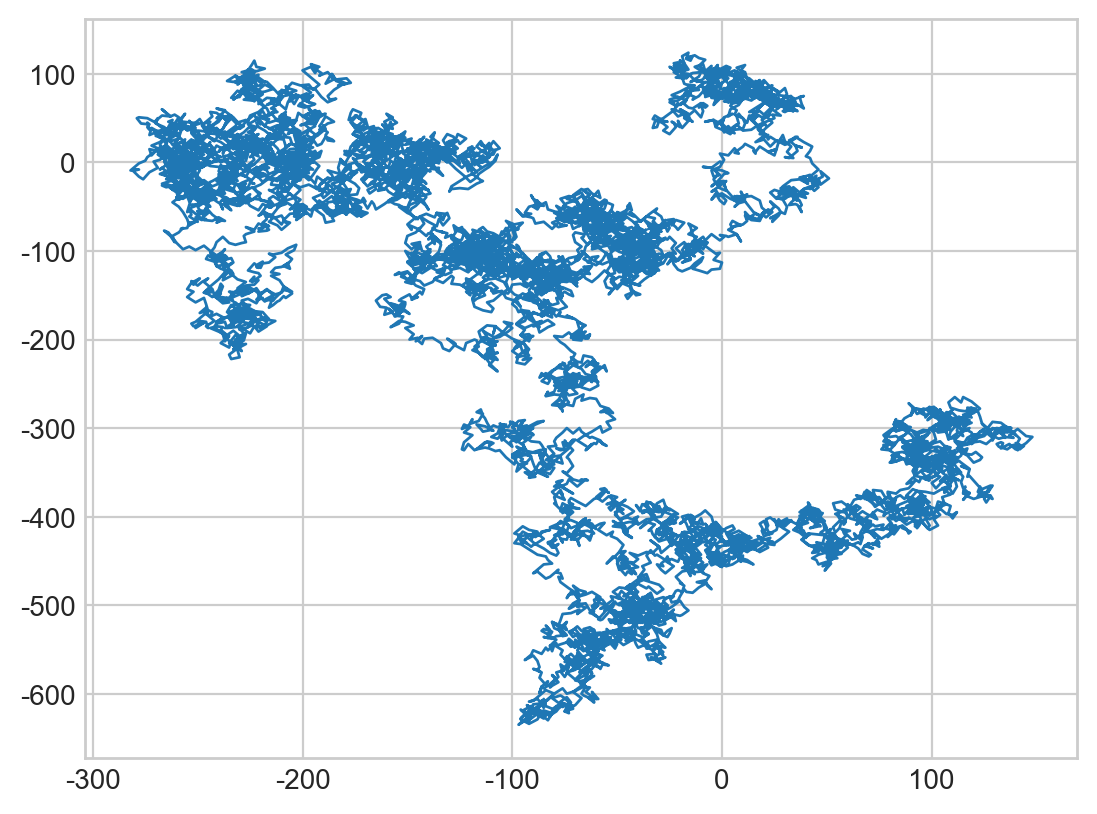

In [6]:
plt.plot(rw.x_values, rw.y_values, linewidth=1)

In [7]:
# 随机游走(重构，计算移动的步长单独拿出来编写一个方法)
from random import choice


class RandomWalk1:
    def __init__(self, numpoints=10000):
        self.numpoints = numpoints
        self.x_values = [0]
        self.y_values = [0]

    def fill_walk(self):
        while (len(self.x_values) < self.numpoints):
            x_step = self.get_step()
            y_step = self.get_step()
            if x_step == 0 and y_step == 0:
                continue

            x = self.x_values[-1]+x_step
            y = self.y_values[-1]+y_step
            self.x_values.append(x)
            self.y_values.append(y)

    def get_step(self):
        self.direction = choice([-1, 1])
        self.distance = choice([1, 2, 3, 4])
        self.step = self.direction*self.distance
        return self.step

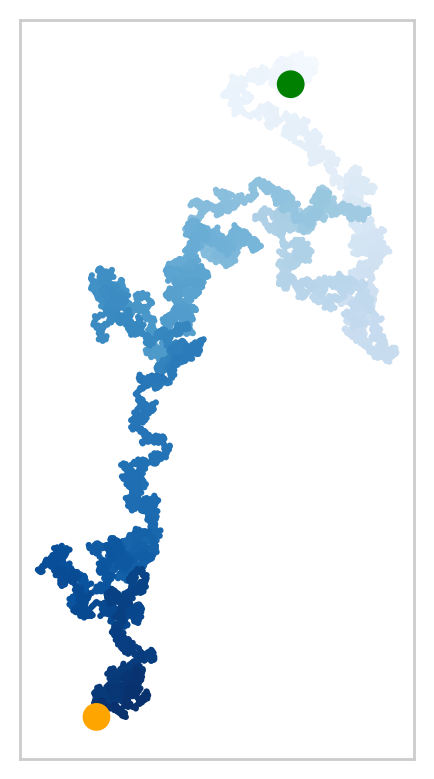

In [8]:
rw = RandomWalk1()
rw.fill_walk()
plt.style.available
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots()
point_numbers = range(rw.numpoints)
ax.scatter(rw.x_values,
           rw.y_values,
           s=5,  # 形状大小
           c=point_numbers,
           cmap=plt.cm.Blues,  # 颜色映射
           edgecolors='none'  # 标记边框的颜色
           )
ax.scatter(0, 0, c='green', s=100, edgecolors='none')
ax.scatter(rw.x_values[-1], rw.y_values[-1], c='orange', s=100, edgecolors='none')
ax.set_aspect('equal')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

In [9]:
# 创建一个骰子类，并设置一个投掷方法
from random import randint


class Die:
    def __init__(self, num_sides=6):
        self.num_sides = num_sides

    def roll(self):
        return randint(1, self.num_sides)

In [10]:
die = Die()
a = []
for i in range(100):
    a.append(die.roll())
print(a)

[4, 1, 1, 6, 1, 1, 6, 3, 6, 2, 2, 2, 4, 1, 2, 4, 1, 3, 6, 2, 4, 4, 1, 3, 6, 2, 6, 3, 2, 2, 3, 4, 1, 2, 6, 4, 1, 4, 3, 2, 3, 1, 3, 2, 5, 4, 6, 3, 5, 5, 2, 2, 3, 2, 4, 4, 6, 3, 1, 4, 4, 4, 5, 4, 2, 5, 2, 2, 4, 5, 2, 2, 5, 4, 5, 1, 6, 6, 2, 3, 2, 4, 3, 2, 5, 5, 1, 3, 4, 2, 3, 2, 3, 6, 2, 2, 3, 4, 4, 2]


In [11]:
# 分析结果
results = []

for i in range(1000):
    result = die.roll()
    results.append(result)
frequencys = []
poss_results = range(1, die.num_sides+1)
for value in poss_results:
    frequency = results.count(value)
    frequencys.append(frequency)
print(frequencys)

[167, 157, 180, 178, 168, 150]


In [17]:
import plotly.express as px
fig = px.bar(x=poss_results, 
             y=frequencys,
             title="Result of Rolling One D6 1000 times",
             labels={'x':'Result', 'y':'Frequency of Result'}
             )
fig.show()